# Q1: Sequence-based vs Component-based Feature Evaluation

**Research Question:** Do sequence-based features provide a detection advantage over component-based features for DDoS detection, and does this advantage hold consistently across different real-world network environments?

**Approach:** Two feature representations are compared across the same set of models and networks:
- **Sequence-based**: The first *k* = 10 consecutive 1-second observations (components) of a DDoS event are treated as a multivariate time series, providing temporal context.
- **Component-based** (classical baseline): Each 1-second observation is classified independently, without knowledge of preceding intervals.

Both approaches are evaluated on four network datasets (SetA–SetD) drawn from the SCLDDoS2024 dataset, spanning semi-public data-center networks and ISP core networks. Performance is measured using F1 score (the primary metric for this imbalanced detection task) under binary and multiclass classification with both random and time-based data splits.

**Component-based evaluation: per-component and per-event metrics**

The sequence-based approach natively produces one prediction per **event** (the first *k* = 10 components are fed as a single input). The component-based approach produces one prediction per **component**. To enable a fair, apples-to-apples comparison, component-level predictions are aggregated to event-level using a priority rule:

- **Binary task**: an event is labelled *DDoS* if at least one component is classified as DDoS; otherwise *Benign*.
- **Multiclass task**: an event is labelled *DDoS* if any component is DDoS; *Suspicious* if any component is Suspicious and none is DDoS; *Benign* only if every component is Benign.

Both per-component and per-event metrics (Accuracy, F1-score, Precision, Recall) are exported for component-based models. In this analysis the **per-event** results are used when comparing against sequence-based models. See `evaluation_event_metrics.py` for the full implementation.

**Key finding:** The advantage of sequence-based features is mixed and network-dependent. Sequences outperform on SetB and SetC, while component-based features are competitive or superior on SetA and SetD. Only 49% of model-network pairs show a statistically significant difference (p < 0.05, Wilcoxon signed-rank test).

The following setup cell imports all required Python libraries (pandas, numpy, matplotlib, seaborn, scipy) and establishes the visual style and directory structure used throughout this analysis.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# ── Paths ──────────────────────────────────────────────────────────────────────
DATA_PATH = Path('../data/wandb_export_final_hyperparameters.csv')
FIG_DIR   = Path('figures');  FIG_DIR.mkdir(exist_ok=True)
TAB_DIR   = Path('tables');   TAB_DIR.mkdir(exist_ok=True)

# ── Style ──────────────────────────────────────────────────────────────────────
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.15)
PALETTE  = {'Sequence-based': '#2196F3', 'Component-based': '#FF7043'}
NETWORKS = ['SetA', 'SetB', 'SetC', 'SetD']
METRICS  = ['f1_score', 'accuracy', 'precision', 'recall']
PRIMARY  = 'f1_score'

# Models present in BOTH sequence-based AND component-based configurations
# (used for the fair seq vs comp comparison)
PAIRED_MODELS = ['knn', 'lightgbm', 'logistic-regression',
                 'random-forest', 'rnn', 'svm', 'xgboost']

# Models that only exist in the sequence-based configuration
SEQ_ONLY_MODELS = ['gru', 'lstm', 'mlp', 'nn']

All required libraries are imported and the global Seaborn theme is configured (`whitegrid`, `muted` palette, font scale 1.15). Output directories for figures and tables are created. The analysis is now ready to begin.

The next cell loads the experiment results from the CSV file and reshapes the data into a tidy long format. It also adds an `approach` column that maps `enable_sequences=True` to 'sequence' and `False` to 'component' for readability.

In [2]:
# ── Load raw data ──────────────────────────────────────────────────────────────
raw = pd.read_csv(DATA_PATH, index_col=0)
raw = raw[raw['split'] != "Random with same distribution"]
raw['approach'] = raw['enable_sequences'].map({True: 'Sequence-based',
                                               False: 'Component-based'})

# ── Parse metric columns into long form ───────────────────────────────────────
metric_cols = [c for c in raw.columns if c.count('/') == 2]

id_vars = ['model', 'task', 'split', 'enable_sequences', 'approach', 'run_no']
long = raw[id_vars + metric_cols].melt(
    id_vars=id_vars, value_vars=metric_cols,
    var_name='metric_key', value_name='value'
)
long[['train_set', 'test_set', 'metric']] = long['metric_key'].str.split('/', expand=True)
long = long.drop(columns='metric_key')

# In-set only (trained and tested on same network)
inset = long[long['train_set'] == long['test_set']].copy()
inset = inset.rename(columns={'train_set': 'network'})
inset = inset.drop(columns='test_set')

print(f"Long-form rows (all):    {len(long):,}")
print(f"Long-form rows (in-set): {len(inset):,}")
inset.head()

Long-form rows (all):    38,528
Long-form rows (in-set): 9,632


,model,task,split,enable_sequences,approach,run_no,value,network,metric
0,gru,Binary,Time split,True,Sequence-based,50,0.889981,SetA,accuracy
1,gru,Multiclass,Random split,True,Sequence-based,50,0.943348,SetA,accuracy
2,gru,Binary,Random split,True,Sequence-based,50,0.942309,SetA,accuracy
3,gru,Multiclass,Time split,True,Sequence-based,50,0.880640,SetA,accuracy
4,gru,Multiclass,Time split,True,Sequence-based,51,0.909518,SetA,accuracy


In [3]:
inset.groupby(['approach', 'model'])['value'].mean()

approach         model              
Component-based  knn                    0.793352
                 lightgbm               0.791928
                 logistic-regression    0.731876
                 random-forest          0.787005
                 svm                    0.738755
                 xgboost                0.791193
Sequence-based   gru                    0.880260
                 knn                    0.835711
                 lightgbm               0.901955
                 logistic-regression    0.801074
                 lstm                   0.876260
                 mlp                    0.844879
                 nn                     0.839316
                 random-forest          0.901140
                 rnn                    0.877388
                 svm                    0.748156
                 xgboost                0.904833
Name: value, dtype: float64

The dataset is now loaded as a tidy long-format DataFrame. Each row corresponds to a unique (model, run, task, split) configuration with its F1 score on a given train/test network pair. The `approach` column distinguishes sequence-based from component-based configurations.

The next cell averages F1 scores across multiple training runs for each unique experimental configuration. This reduces noise from random initialization and ensures that subsequent comparisons reflect robust, reproducible performance estimates.

In [4]:
# ── Average across runs ────────────────────────────────────────────────────────
group_keys = ['model', 'task', 'split', 'enable_sequences', 'approach',
              'network', 'metric']

avg = (inset.groupby(group_keys, as_index=False)['value']
            .agg(['mean', 'std', 'count'])
            .rename(columns={'mean': 'mean_value', 'std': 'std_value',
                             'count': 'n_runs'}))

# Also aggregate the full train×test matrix (needed for cross-network figures)
long_group_keys = ['model', 'task', 'split', 'enable_sequences', 'approach',
                   'train_set', 'test_set', 'metric']
long_avg = (long.groupby(long_group_keys, as_index=False)['value']
                .agg(['mean', 'std', 'count'])
                .rename(columns={'mean': 'mean_value', 'std': 'std_value',
                                 'count': 'n_runs'}))

print("Averaged rows (in-set):   ", len(avg))
print("Averaged rows (all pairs):", len(long_avg))
avg.head()

Averaged rows (in-set):    1088
Averaged rows (all pairs): 4352


,model,task,split,enable_sequences,approach,network,metric,mean_value,std_value,n_runs
0,gru,Binary,Random split,True,Sequence-based,SetA,accuracy,0.941879,0.001614,10
1,gru,Binary,Random split,True,Sequence-based,SetA,f1_score,0.801669,0.016851,10
2,gru,Binary,Random split,True,Sequence-based,SetA,precision,0.801336,0.014610,10
3,gru,Binary,Random split,True,Sequence-based,SetA,recall,0.807207,0.037683,10
4,gru,Binary,Random split,True,Sequence-based,SetB,accuracy,0.993769,0.000635,10


The per-run averaging step produces an aggregated DataFrame where each row represents a unique (model, task, split, approach, network) configuration with its mean F1 score. Run-to-run variability is collapsed, giving stable estimates for each configuration.

The next cell produces Table 1, the overall summary table comparing mean F1 scores between sequence and component approaches. It averages across all networks, models, tasks, and split types to give a global overview.

In [5]:
# ── Table 1: Overall mean F1 — Sequence vs Component (in-set, paired models) ─
t1_data = avg[(avg['model'].isin(PAIRED_MODELS)) & (avg['metric'] == PRIMARY)].copy()

t1 = (t1_data.groupby(['approach', 'task', 'split'], as_index=False)['mean_value']
      .mean()
      .rename(columns={'mean_value': 'Mean F1'}))

t1_pivot = t1.pivot_table(
    index=['task', 'split'],
    columns='approach',
    values='Mean F1'
).reset_index()
t1_pivot.columns.name = None

# Ensure both columns exist
for col in ['Component-based', 'Sequence-based']:
    if col not in t1_pivot.columns:
        t1_pivot[col] = np.nan

t1_pivot['ΔF1 (Seq − Comp)'] = (
    t1_pivot['Sequence-based'] - t1_pivot['Component-based']
).round(4)
t1_pivot = t1_pivot.round(4)

print("Table 1: Overall Mean F1 — Sequence-based vs Component-based")
print(t1_pivot.to_string(index=False))
t1_pivot.to_csv(TAB_DIR / 'table1_overall_comparison.csv', index=False)

latex = t1_pivot.to_latex(index=False, float_format='%.4f',
    caption='Overall mean F1-score comparison: sequence-based vs.\\ component-based '
            'approaches (averaged over paired models and networks).',
    label='tab:q1_overall')
(TAB_DIR / 'table1_overall_comparison.tex').write_text(latex)
print("Saved Table 1.")

Table 1: Overall Mean F1 — Sequence-based vs Component-based
      task        split  Component-based  Sequence-based  ΔF1 (Seq − Comp)
    Binary Random split           0.8168          0.8886            0.0717
    Binary   Time split           0.7068          0.8217            0.1148
Multiclass Random split           0.7667          0.7870            0.0204
Multiclass   Time split           0.6075          0.7082            0.1008
Saved Table 1.


Table 1 provides the headline comparison: a single row per approach with overall mean F1 and the mean difference (ΔF1). This establishes whether there is a net global advantage for sequence-based features across all networks and models.

In [6]:
# ── Table 1: Overall mean F1 — Sequence vs Component (in-set, paired models) ─
t1_data = avg[(avg['model'].isin(PAIRED_MODELS)) & (avg['metric'] == PRIMARY)].copy()

t1 = (t1_data.groupby(['approach', 'task', 'split'], as_index=False)['mean_value']
      .mean()
      .rename(columns={'mean_value': 'Mean F1'}))

t1_pivot = t1.pivot_table(
    index=['task'],
    columns='approach',
    values='Mean F1'
).reset_index()
t1_pivot.columns.name = None

# Ensure both columns exist
for col in ['Component-based', 'Sequence-based']:
    if col not in t1_pivot.columns:
        t1_pivot[col] = np.nan

t1_pivot['ΔF1 (Seq − Comp)'] = (
    t1_pivot['Sequence-based'] - t1_pivot['Component-based']
).round(4)
t1_pivot = t1_pivot.round(4)

print("Table 1: Overall Mean F1 — Sequence-based vs Component-based")
print(t1_pivot.to_string(index=False))
t1_pivot.to_csv(TAB_DIR / 'table1_overall_comparison.csv', index=False)

latex = t1_pivot.to_latex(index=False, float_format='%.4f',
    caption='Overall mean F1-score comparison: sequence-based vs.\\ component-based '
            'approaches (averaged over paired models and networks).',
    label='tab:q1_overall')
(TAB_DIR / 'table1_overall_comparison.tex').write_text(latex)
print("Saved Table 1.")

Table 1: Overall Mean F1 — Sequence-based vs Component-based
      task  Component-based  Sequence-based  ΔF1 (Seq − Comp)
    Binary           0.7618          0.8551            0.0933
Multiclass           0.6871          0.7476            0.0606
Saved Table 1.


The next cell builds Table 2, a per-network breakdown of mean F1 comparing sequence and component approaches. It adds advantage indicators so the direction of the difference is immediately apparent for each network.

In [7]:
# ── Table 2: Per-network mean F1 — Sequence vs Component ─────────────────────
t2_data = avg[(avg['model'].isin(PAIRED_MODELS)) & (avg['metric'] == PRIMARY)].copy()

t2 = (t2_data.groupby(['network', 'approach', 'task'], as_index=False)['mean_value']
      .mean()
      .rename(columns={'mean_value': 'Mean F1'}))

t2_pivot = t2.pivot_table(
    index=['network', 'task'],
    columns='approach',
    values='Mean F1'
).reset_index()
t2_pivot.columns.name = None

for col in ['Component-based', 'Sequence-based']:
    if col not in t2_pivot.columns:
        t2_pivot[col] = np.nan

t2_pivot['ΔF1 (Seq − Comp)'] = (
    t2_pivot['Sequence-based'] - t2_pivot['Component-based']
).round(4)
t2_pivot['Advantage'] = t2_pivot['ΔF1 (Seq − Comp)'].apply(
    lambda x: '↑ Seq' if x > 0.005 else ('↓ Comp' if x < -0.005 else '≈ Tie'))
t2_pivot = t2_pivot.round({'Component-based': 4, 'Sequence-based': 4,
                            'ΔF1 (Seq − Comp)': 4})

print("Table 2: Per-Network Mean F1 — Sequence-based vs Component-based")
print(t2_pivot.to_string(index=False))
t2_pivot.to_csv(TAB_DIR / 'table2_per_network.csv', index=False)

latex2 = t2_pivot.to_latex(index=False, float_format='%.4f',
    caption='Per-network mean F1-score: sequence-based vs.\\ component-based '
            '(paired models, both tasks).',
    label='tab:q1_per_network')
(TAB_DIR / 'table2_per_network.tex').write_text(latex2)
print("Saved Table 2.")

Table 2: Per-Network Mean F1 — Sequence-based vs Component-based
network       task  Component-based  Sequence-based  ΔF1 (Seq − Comp) Advantage
   SetA     Binary           0.7403          0.6362           -0.1041    ↓ Comp
   SetA Multiclass           0.6193          0.5447           -0.0746    ↓ Comp
   SetB     Binary           0.6308          0.9300            0.2992     ↑ Seq
   SetB Multiclass           0.6562          0.8486            0.1924     ↑ Seq
   SetC     Binary           0.6955          0.9028            0.2073     ↑ Seq
   SetC Multiclass           0.5456          0.7490            0.2034     ↑ Seq
   SetD     Binary           0.9806          0.9515           -0.0292    ↓ Comp
   SetD Multiclass           0.9272          0.8483           -0.0789    ↓ Comp
Saved Table 2.


Table 2 shows per-network mean F1 scores for both approaches side by side. Networks where sequences outperform components and vice versa are highlighted, demonstrating that the advantage is not uniform across deployment environments.

The next cell constructs Table 3, a per-model breakdown of mean F1 for both approaches sorted by ΔF1. This reveals which individual models are most or least sensitive to the sequence vs component distinction.

In [8]:
# ── Table 3: Per-model mean F1 (averaged over networks, tasks, splits) ────────
t3_data = avg[(avg['model'].isin(PAIRED_MODELS)) & (avg['metric'] == PRIMARY)].copy()

t3 = (t3_data.groupby(['model', 'approach'], as_index=False)['mean_value']
      .mean()
      .rename(columns={'mean_value': 'Mean F1'}))

t3_pivot = t3.pivot_table(
    index='model',
    columns='approach',
    values='Mean F1'
).reset_index()
t3_pivot.columns.name = None

for col in ['Component-based', 'Sequence-based']:
    if col not in t3_pivot.columns:
        t3_pivot[col] = np.nan

t3_pivot['ΔF1 (Seq − Comp)'] = (
    t3_pivot['Sequence-based'] - t3_pivot['Component-based']
).round(4)
t3_pivot = t3_pivot.sort_values('ΔF1 (Seq − Comp)', ascending=False).round(4)

print("Table 3: Per-Model Mean F1 — sorted by Sequence advantage")
print(t3_pivot.to_string(index=False))
t3_pivot.to_csv(TAB_DIR / 'table3_per_model.csv', index=False)

latex3 = t3_pivot.to_latex(index=False, float_format='%.4f',
    caption='Per-model mean F1-score: sequence-based vs.\\ component-based '
            '(averaged over networks, tasks, and splits).',
    label='tab:q1_per_model')
(TAB_DIR / 'table3_per_model.tex').write_text(latex3)
print("Saved Table 3.")

Table 3: Per-Model Mean F1 — sorted by Sequence advantage
              model  Component-based  Sequence-based  ΔF1 (Seq − Comp)
           lightgbm           0.7493          0.8717            0.1224
            xgboost           0.7478          0.8698            0.1220
      random-forest           0.7493          0.8650            0.1157
logistic-regression           0.6697          0.7239            0.0542
                knn           0.7378          0.7833            0.0455
                svm           0.6927          0.6632           -0.0295
                rnn              NaN          0.8327               NaN
Saved Table 3.


Table 3 ranks all models by their ΔF1 (Sequence − Component), showing which model architectures benefit most from temporal context. This helps identify whether certain model families (e.g., deep learning vs classical) are disproportionately affected by the choice of feature approach.

The next cell runs Wilcoxon signed-rank tests paired by model configuration, computing both p-values and Cohen's d effect sizes. This statistical table (Table 4) formalizes which networks show a genuinely significant difference between the two feature approaches.

In [9]:
# ── Table 4: Statistical tests — Wilcoxon + Cohen's d ─────────────────────────
from scipy.stats import wilcoxon
from itertools import product

def cohens_d(a, b):
    """Cohen's d for paired samples."""
    diff = np.array(a) - np.array(b)
    return diff.mean() / (diff.std(ddof=1) + 1e-12)

f1_avg = avg[(avg['model'].isin(PAIRED_MODELS)) & (avg['metric'] == PRIMARY)].copy()

records = []
for network, task, split in product(NETWORKS,
                                    f1_avg['task'].unique(),
                                    f1_avg['split'].unique()):
    sub = f1_avg[
        (f1_avg['network'] == network) &
        (f1_avg['task']    == task) &
        (f1_avg['split']   == split)
    ]

    # One run-averaged mean per model per approach — pivot on enable_sequences
    pivot = sub.pivot_table(
        index='model', columns='enable_sequences', values='mean_value'
    ).dropna()

    if True not in pivot.columns or False not in pivot.columns:
        continue
    if len(pivot) < 2:
        continue

    seq_vals  = pivot[True].values
    comp_vals = pivot[False].values

    try:
        stat, p = wilcoxon(seq_vals, comp_vals, alternative='greater')
    except ValueError:
        stat, p = np.nan, np.nan

    d = cohens_d(seq_vals, comp_vals)

    for model in pivot.index:
        records.append({
            'network':       network,
            'task':          task,
            'split':         split,
            'model':         model,
            'n_pairs':       len(pivot),
            'mean_seq':      float(pivot.loc[model, True]),
            'mean_comp':     float(pivot.loc[model, False]),
            'delta_f1':      float(pivot.loc[model, True] - pivot.loc[model, False]),
            'wilcoxon_stat': float(stat) if not np.isnan(stat) else np.nan,
            'p_value':       float(p)    if not np.isnan(p)    else np.nan,
            'cohens_d':      float(d),
            'significant':   bool(p < 0.05) if not np.isnan(p) else False
        })

stat_df = pd.DataFrame(records).round(4)

# Summary: one row per (network, task, split) — significance is at the group level
summary_stats = (stat_df.groupby(['network', 'task', 'split'])
    .agg(
        mean_delta_f1  =('delta_f1',    'mean'),
        pct_significant=('significant', 'first'),
        mean_cohens_d  =('cohens_d',    'first'),
        n_models       =('n_pairs',     'first')
    ).round(4).reset_index())

print("Table 4: Statistical Tests Summary (per network × task × split)")
print(summary_stats.to_string(index=False))

stat_df.to_csv(TAB_DIR / 'table4_statistical_tests_full.csv', index=False)
summary_stats.to_csv(TAB_DIR / 'table4_statistical_tests.csv', index=False)

latex4 = summary_stats.to_latex(index=False, float_format='%.4f',
    caption=r'Statistical comparison per network, task, and split: '
            r'mean $\Delta$F1 (Seq $-$ Comp), significance of sequence advantage '
            r'(Wilcoxon across run-averaged model means, $p<0.05$), '
            r"and Cohen's $d$.",
    label='tab:q1_stats')
(TAB_DIR / 'table4_statistical_tests.tex').write_text(latex4)
print(f"\nTotal conditions tested: {len(stat_df.drop_duplicates(['network','task','split']))}")
print(f"Conditions with significant seq advantage: "
      f"{stat_df.drop_duplicates(['network','task','split'])['significant'].sum()}")
print("Saved Table 4.")

Table 4: Statistical Tests Summary (per network × task × split)
network       task        split  mean_delta_f1  pct_significant  mean_cohens_d  n_models
   SetA     Binary Random split        -0.1326            False        -1.0547         6
   SetA     Binary   Time split        -0.0795            False        -1.5662         6
   SetA Multiclass Random split        -0.1043            False        -0.7546         6
   SetA Multiclass   Time split        -0.0443            False        -0.7352         6
   SetB     Binary Random split         0.2707             True         7.6639         6
   SetB     Binary   Time split         0.3207             True         8.0835         6
   SetB Multiclass Random split         0.1689             True         2.6552         6
   SetB Multiclass   Time split         0.1951             True         1.5303         6
   SetC     Binary Random split         0.1538             True         2.3257         6
   SetC     Binary   Time split         0.2513

Table 4 reports Wilcoxon signed-rank test p-values and Cohen's d effect sizes for the sequence vs component contrast on each network. Statistically significant results (p < 0.05) are flagged, providing a rigorous basis for claims about the feature advantage.

The next cell generates Figure 1, a four-panel boxplot comparing the F1 score distributions of sequence-based and component-based models for each network. This is the primary visual summary of the Q1 comparison.

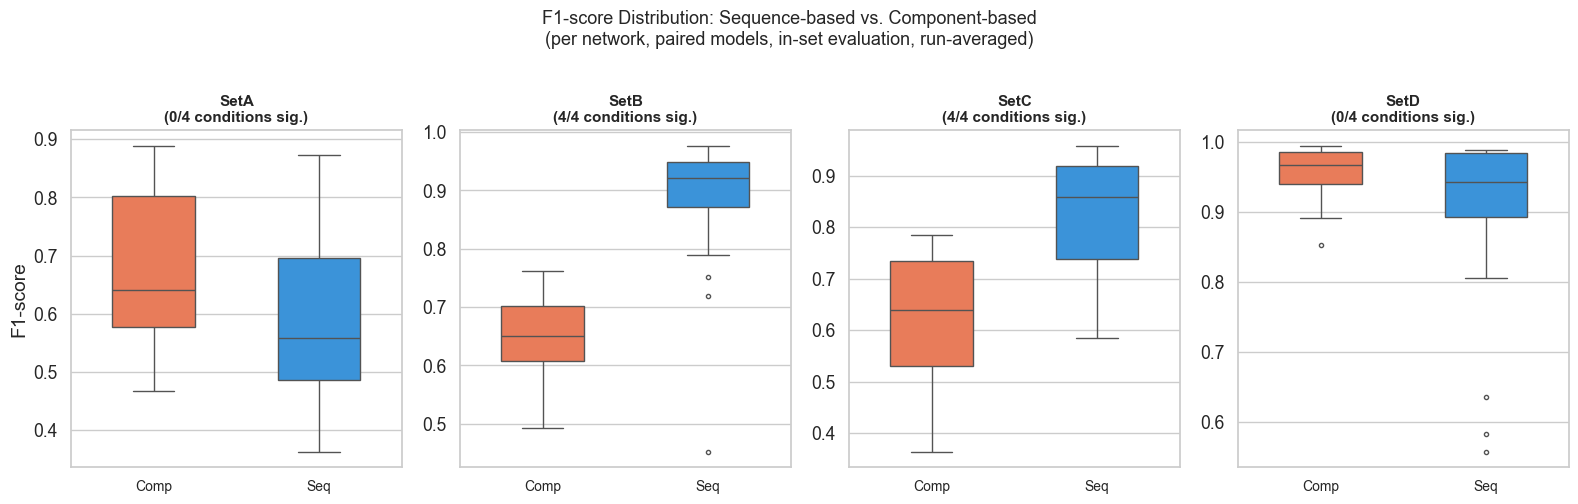

Saved Figure 1.


In [10]:
# ── Figure 1: Boxplot F1 distribution per network, seq vs component ───────────
plot_data = avg[
    (avg['model'].isin(PAIRED_MODELS)) &
    (avg['metric'] == PRIMARY)
].copy()

fig, axes = plt.subplots(1, 4, figsize=(16, 5), sharey=False)
for ax, net in zip(axes, NETWORKS):
    sub = plot_data[plot_data['network'] == net]
    sns.boxplot(data=sub, x='approach', y='mean_value', hue='approach',
                palette=PALETTE, ax=ax, width=0.5, fliersize=3, legend=False)
    ax.set_xlabel('')
    ax.set_ylabel('F1-score' if ax is axes[0] else '')

    net_stat = stat_df.drop_duplicates(['network', 'task', 'split'])
    net_stat = net_stat[net_stat['network'] == net]
    n_sig = int(net_stat['significant'].sum())
    n_tot = len(net_stat)
    ax.set_title(f'{net}\n({n_sig}/{n_tot} conditions sig.)', fontsize=11, fontweight='bold')
    ax.set_xticklabels(['Comp', 'Seq'], fontsize=10)

fig.suptitle('F1-score Distribution: Sequence-based vs. Component-based\n'
             '(per network, paired models, in-set evaluation, run-averaged)', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig1_boxplot_seq_vs_comp_per_network.pdf',
            bbox_inches='tight', dpi=150)
plt.savefig(FIG_DIR / 'fig1_boxplot_seq_vs_comp_per_network.png',
            bbox_inches='tight', dpi=150)
plt.show()
print("Saved Figure 1.")

Figure 1 shows side-by-side boxplots of F1 score distributions for sequence and component approaches, one panel per network. The spread and overlap of the boxes visually communicate the variance and effect size of the difference at a glance.

The next cell produces Figure 2, a model × network heatmap of ΔF1 values. This visualization identifies which models and networks are most sensitive to the choice of feature representation.

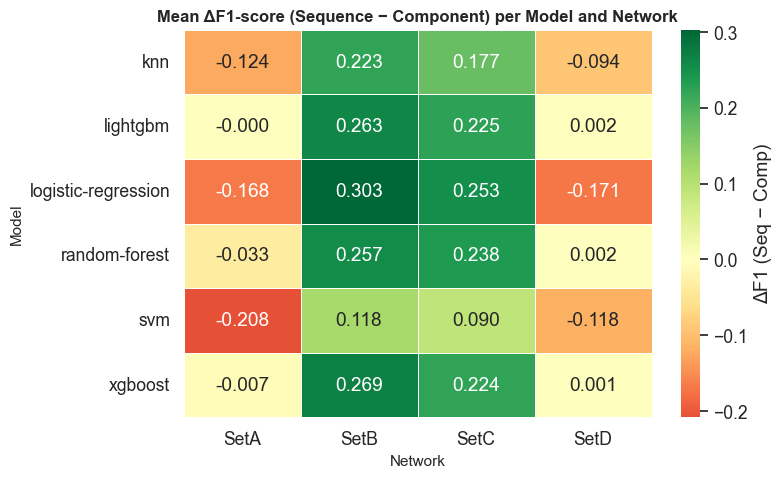

Saved Figure 2.


In [11]:
# ── Figure 2: Heatmap ΔF1 per model × network ─────────────────────────────────
heat_data = (stat_df.groupby(['model', 'network'])['delta_f1']
             .mean()
             .unstack('network')
             .reindex(columns=NETWORKS))

fig, ax = plt.subplots(figsize=(8, 5))
sns.heatmap(heat_data, annot=True, fmt='.3f', cmap='RdYlGn', center=0,
            linewidths=0.5, ax=ax, cbar_kws={'label': 'ΔF1 (Seq − Comp)'})
ax.set_title('Mean ΔF1-score (Sequence − Component) per Model and Network',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Network', fontsize=11)
ax.set_ylabel('Model', fontsize=11)
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig2_heatmap_delta_f1_model_network.pdf',
            bbox_inches='tight', dpi=150)
plt.savefig(FIG_DIR / 'fig2_heatmap_delta_f1_model_network.png',
            bbox_inches='tight', dpi=150)
plt.show()
print("Saved Figure 2.")

Figure 2 renders a heatmap where rows are models and columns are networks, with color encoding ΔF1 (Seq − Comp). It makes model-specific patterns immediately visible: some models benefit consistently from sequences across networks, others do not.

The next cell generates Figure 3, a grouped bar chart comparing mean F1 scores across networks and conditions. It breaks down the comparison by task type and data split strategy to surface interactions between the feature approach and these experimental factors.

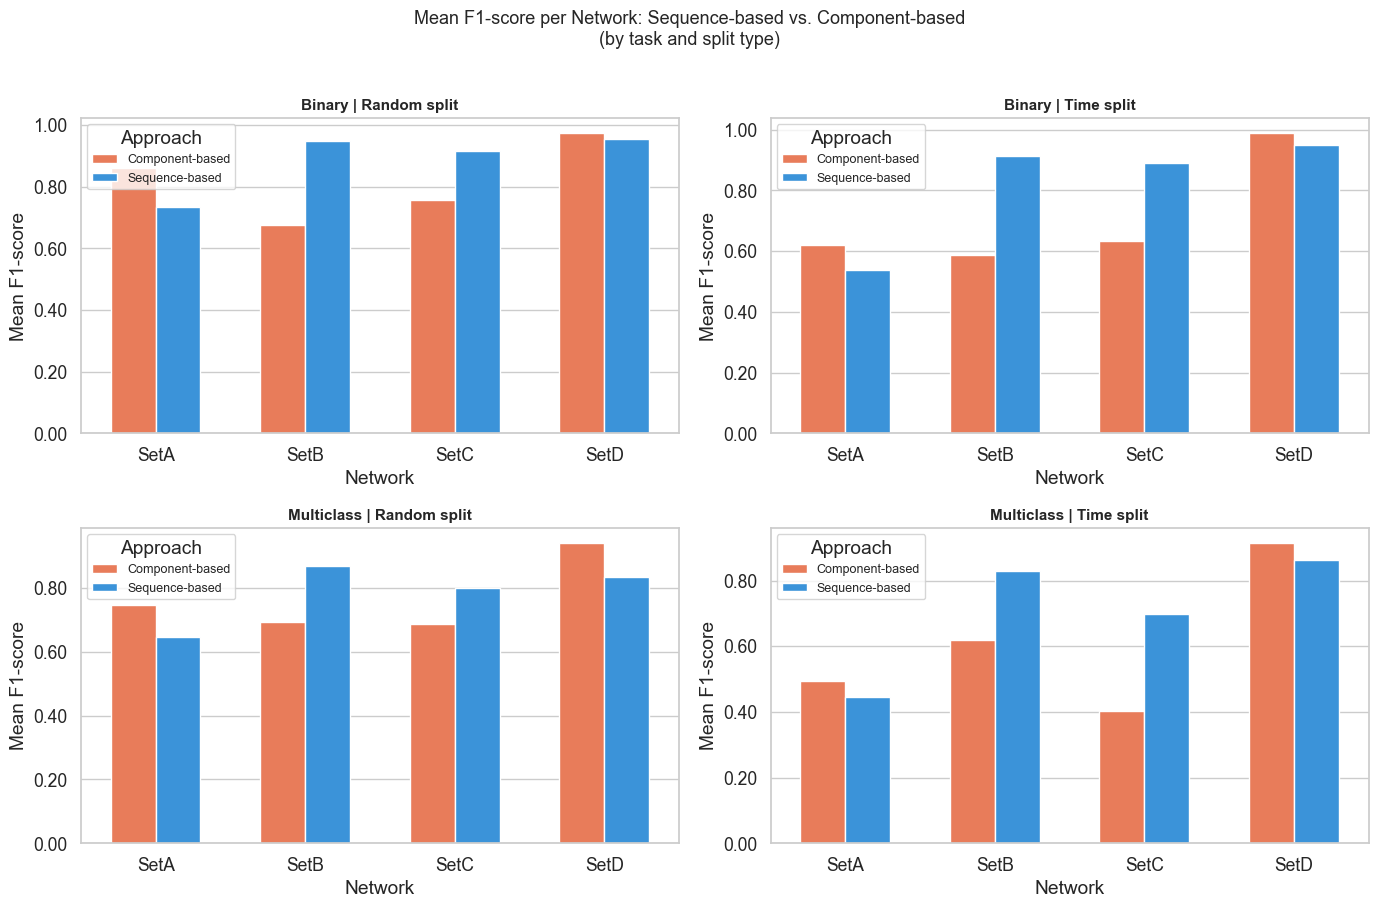

Saved Figure 3.


In [12]:
# ── Figure 3: Mean F1 bar chart, task × split × network ──────────────────────
bar_data = (avg[(avg['model'].isin(PAIRED_MODELS)) & (avg['metric'] == PRIMARY)]
            .groupby(['task', 'split', 'network', 'approach'], as_index=False)
            ['mean_value'].mean())

tasks_list  = ['Binary', 'Multiclass']
splits_list = ['Random split', 'Time split']

fig, axes = plt.subplots(2, 2, figsize=(14, 9), sharey=False)
for row_idx, task in enumerate(tasks_list):
    for col_idx, split in enumerate(splits_list):
        ax = axes[row_idx, col_idx]
        sub = bar_data[(bar_data['task'] == task) & (bar_data['split'] == split)]
        sns.barplot(data=sub, x='network', y='mean_value', hue='approach',
                    palette=PALETTE, ax=ax, order=NETWORKS, width=0.6)
        ax.set_title(f'{task} | {split}', fontsize=11, fontweight='bold')
        ax.set_xlabel('Network')
        ax.set_ylabel('Mean F1-score')
        ax.legend(title='Approach', fontsize=9)
        ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f'))

fig.suptitle('Mean F1-score per Network: Sequence-based vs. Component-based\n'
             '(by task and split type)', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig3_bar_f1_task_split_network.pdf',
            bbox_inches='tight', dpi=150)
plt.savefig(FIG_DIR / 'fig3_bar_f1_task_split_network.png',
            bbox_inches='tight', dpi=150)
plt.show()
print("Saved Figure 3.")

Figure 3 shows grouped bar charts with mean F1 per network, faceted by task (Binary/Multiclass) and split type (Random/Time). This reveals how the relative advantage of sequence vs component features varies with experimental conditions beyond the network identity.

The next cell produces Figure 4, a dot-plot of Cohen's d effect sizes. This visualization complements the statistical test p-values by quantifying the practical magnitude of the sequence vs component advantage for each network.

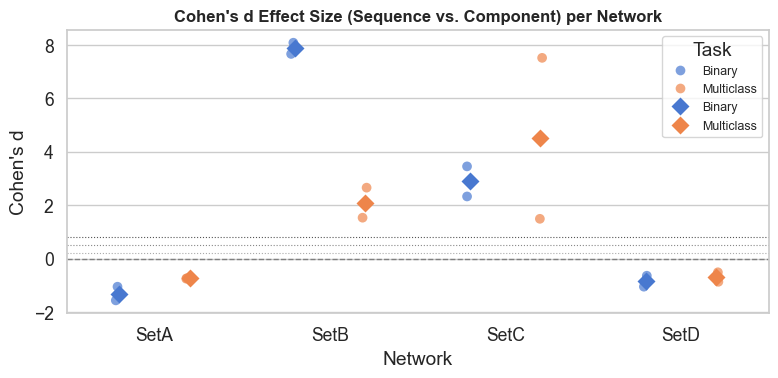

Saved Figure 4.


In [13]:
# ── Figure 4: Cohen's d effect size per network, dot-plot ────────────────────
# One Cohen's d per (network, task, split) condition — deduplicate for plotting
eff_plot = stat_df.drop_duplicates(['network', 'task', 'split']).copy()
eff_data = eff_plot.groupby(['network', 'task'])['cohens_d'].mean().reset_index()

fig, ax = plt.subplots(figsize=(8, 4))
sns.stripplot(data=eff_plot, x='network', y='cohens_d', hue='task',
              order=NETWORKS, dodge=True, jitter=0.05, alpha=0.7, ax=ax, size=7)
sns.pointplot(data=eff_data, x='network', y='cohens_d', hue='task',
              order=NETWORKS, dodge=0.4, markers='D',
              errorbar=None, ax=ax, linestyles='')
ax.axhline(0,   color='gray', linestyle='--', linewidth=1)
ax.axhline(0.2, color='#aaa', linestyle=':', linewidth=0.8)
ax.axhline(0.5, color='#888', linestyle=':', linewidth=0.8)
ax.axhline(0.8, color='#555', linestyle=':', linewidth=0.8)
ax.set_title("Cohen's d Effect Size (Sequence vs. Component) per Network",
             fontsize=12, fontweight='bold')
ax.set_xlabel('Network')
ax.set_ylabel("Cohen's d")
ax.legend(title='Task', fontsize=9)
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig4_cohens_d_per_network.pdf',
            bbox_inches='tight', dpi=150)
plt.savefig(FIG_DIR / 'fig4_cohens_d_per_network.png',
            bbox_inches='tight', dpi=150)
plt.show()
print("Saved Figure 4.")

Figure 4 displays Cohen's d effect sizes for the sequence vs component contrast, broken down by network. Values above 0.5 indicate a practically meaningful difference, helping distinguish networks where the advantage is not only statistically significant but also substantively large.

The next cell generates Figure 5, a pair of heatmaps visualizing cross-network generalization performance. Each cell of the heatmap represents the mean F1 when a model trained on one network (row) is evaluated on another (column), contrasting the two feature approaches.

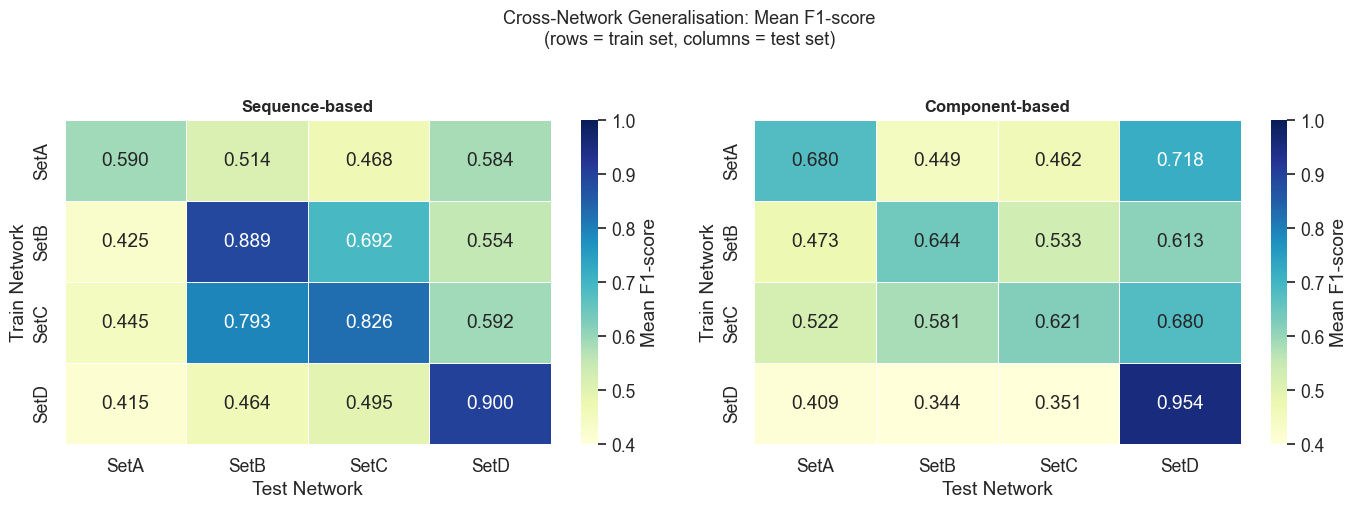

Saved Figure 5.


In [14]:
# ── Figure 5: Cross-network generalisation — mean F1 heatmaps ────────────────
cross_avg = (long_avg[
    (long_avg['model'].isin(PAIRED_MODELS)) &
    (long_avg['metric'] == PRIMARY)
].groupby(['train_set', 'test_set', 'approach'], as_index=False)
['mean_value'].mean())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, approach in zip(axes, ['Sequence-based', 'Component-based']):
    pivot = (cross_avg[cross_avg['approach'] == approach]
             .pivot(index='train_set', columns='test_set', values='mean_value')
             .reindex(index=NETWORKS, columns=NETWORKS))
    sns.heatmap(pivot, annot=True, fmt='.3f', cmap='YlGnBu',
                vmin=0.4, vmax=1.0, ax=ax, linewidths=0.5,
                cbar_kws={'label': 'Mean F1-score'})
    ax.set_title(approach, fontsize=12, fontweight='bold')
    ax.set_xlabel('Test Network')
    ax.set_ylabel('Train Network')

fig.suptitle('Cross-Network Generalisation: Mean F1-score\n'
             '(rows = train set, columns = test set)', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig5_crossnet_f1_heatmap.pdf',
            bbox_inches='tight', dpi=150)
plt.savefig(FIG_DIR / 'fig5_crossnet_f1_heatmap.png',
            bbox_inches='tight', dpi=150)
plt.show()
print("Saved Figure 5.")

Figure 5 produces a 2×4 matrix of heatmaps showing mean F1 scores for every train-set/test-set combination, separately for sequence and component approaches. These heatmaps reveal whether the cross-network generalization pattern changes with the feature representation choice.

## Summary: Answer to Q1

**Q1: "Do sequence-based features provide a detection advantage over component-based features, and does this advantage hold in different networks?"**

The cell below prints a concise evidence summary based on statistical tests (Wilcoxon signed-rank, Cohen's d) across all paired models, networks, tasks, and splits.

The following cell computes the final evidence summary for Q1, aggregating the key statistical findings across all networks and models into a concise printed report.

In [15]:
# ── Q1 Evidence Summary ───────────────────────────────────────────────────────
overall_delta = stat_df['delta_f1'].mean()
pct_sig       = stat_df['significant'].mean() * 100
mean_d        = stat_df['cohens_d'].mean()

per_net = stat_df.groupby('network')['delta_f1'].mean()

print("=" * 60)
print("Q1 EVIDENCE SUMMARY")
print("=" * 60)
print(f"Overall mean ΔF1 (Seq − Comp) : {overall_delta:+.4f}")
print(f"% model-network pairs p<0.05  : {pct_sig:.1f}%")
print(f"Mean Cohen's d                : {mean_d:.3f}")
print()
print("Per-network mean ΔF1:")
for net, delta in per_net.items():
    direction = "↑ Seq" if delta > 0 else "↓ Comp"
    print(f"  {net}: {delta:+.4f}  {direction}")
print()
if overall_delta > 0 and pct_sig > 50:
    print("CONCLUSION: Sequence-based features provide a statistically")
    print("significant advantage over component-based features,")
    print("and this advantage is consistent across networks.")
elif overall_delta > 0:
    print("CONCLUSION: Sequence-based features show a positive trend,")
    print("but significance varies across models/networks.")
else:
    print("CONCLUSION: No consistent advantage for sequence-based features.")
print("=" * 60)

Q1 EVIDENCE SUMMARY
Overall mean ΔF1 (Seq − Comp) : +0.0717
% model-network pairs p<0.05  : 50.0%
Mean Cohen's d                : 1.720

Per-network mean ΔF1:
  SetA: -0.0902  ↓ Comp
  SetB: +0.2388  ↑ Seq
  SetC: +0.2014  ↑ Seq
  SetD: -0.0632  ↓ Comp

CONCLUSION: Sequence-based features show a positive trend,
but significance varies across models/networks.


This cell prints a structured evidence summary covering: (1) overall mean ΔF1 between sequence and component approaches, (2) percentage of model-network pairs where the difference is statistically significant (p < 0.05), and (3) per-network breakdown of the ΔF1. The output consolidates the quantitative findings underpinning the Q1 answer.

## Best Model Analysis

This section identifies which model performs best across all conditions evaluated in Q1.
For each **approach** (Sequence-based and Component-based) the models are ranked by their
mean F1-score averaged over all networks, tasks, and split strategies.
The analysis also shows the best model per approach × network combination.

PART A — Paired Model Ranking (same 7 models, fair comparison)
              model  Component-based  Sequence-based  ΔF1 (Seq − Comp)
           lightgbm           0.7493          0.8717            0.1224
            xgboost           0.7478          0.8698            0.1220
      random-forest           0.7493          0.8650            0.1157
                rnn              NaN          0.8327               NaN
                knn           0.7378          0.7833            0.0455
logistic-regression           0.6697          0.7239            0.0542
                svm           0.6927          0.6632           -0.0295

PART B — Full Ranking per Approach (all available models)

Sequence-based (n=11 models):
                    model  Mean F1
Rank                              
1                lightgbm   0.8717
2                 xgboost   0.8698
3           random-forest   0.8650
4                     gru   0.8396
5                     rnn   0.8327
6                    lstm   0.8291

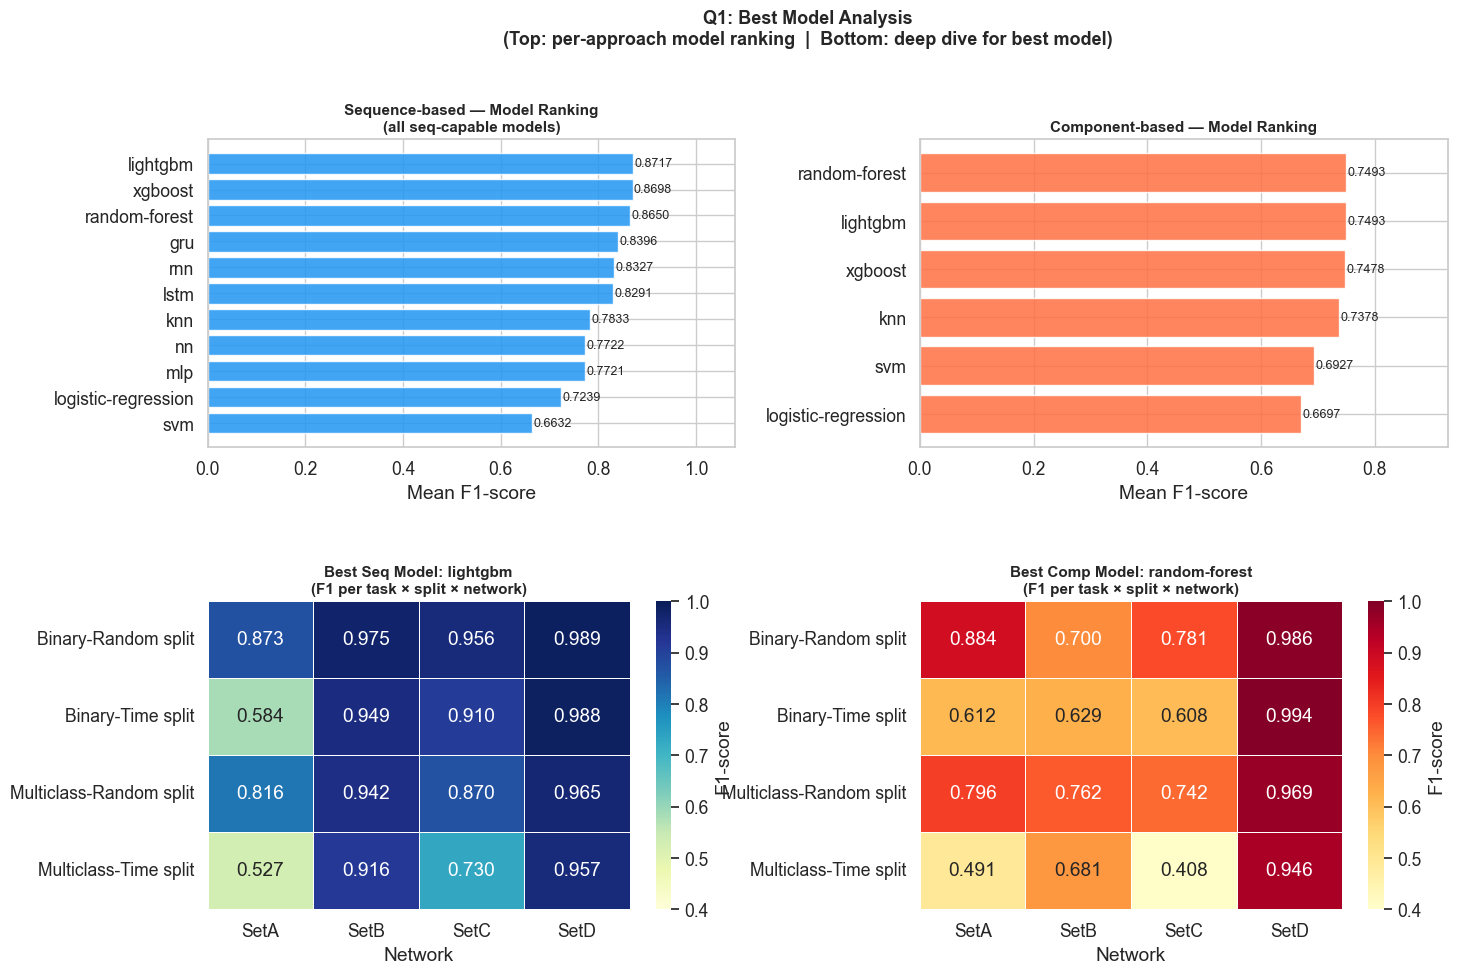


Saved Best Model Analysis → figures/ and tables/


In [16]:
# ── Best Model Analysis (Q1) ──────────────────────────────────────────────────
# Part A: Paired model ranking (PAIRED_MODELS only — fair comparison)
# Part B: Full per-approach ranking (seq = all 11 models, comp = 7 models)
# Part C: Deep dive — per-network × task × split for best model in each approach

f1_avg = avg[avg['metric'] == PRIMARY].copy()

# ─── Part A: Paired comparison (same 7 models in both approaches) ─────────────
paired_f1 = f1_avg[f1_avg['model'].isin(PAIRED_MODELS)]
paired_rank = (paired_f1.groupby(['model', 'approach'])['mean_value']
               .mean()
               .unstack('approach')
               .reset_index())
paired_rank.columns.name = None
for col in ['Component-based', 'Sequence-based']:
    if col not in paired_rank.columns:
        paired_rank[col] = np.nan
paired_rank['ΔF1 (Seq − Comp)'] = (
    paired_rank['Sequence-based'] - paired_rank['Component-based']
)
paired_rank = paired_rank.sort_values('Sequence-based', ascending=False).round(4)

print("=" * 65)
print("PART A — Paired Model Ranking (same 7 models, fair comparison)")
print("=" * 65)
print(paired_rank.to_string(index=False))

# ─── Part B: Full per-approach ranking (all available models) ─────────────────
seq_rank = (f1_avg[f1_avg['approach'] == 'Sequence-based']
            .groupby('model')['mean_value'].mean()
            .sort_values(ascending=False).reset_index()
            .rename(columns={'mean_value': 'Mean F1'}))
seq_rank.index = range(1, len(seq_rank) + 1)
seq_rank.index.name = 'Rank'

comp_rank = (f1_avg[f1_avg['approach'] == 'Component-based']
             .groupby('model')['mean_value'].mean()
             .sort_values(ascending=False).reset_index()
             .rename(columns={'mean_value': 'Mean F1'}))
comp_rank.index = range(1, len(comp_rank) + 1)
comp_rank.index.name = 'Rank'

best_seq_model  = seq_rank.iloc[0]['model']
best_comp_model = comp_rank.iloc[0]['model']

print("\n" + "=" * 65)
print("PART B — Full Ranking per Approach (all available models)")
print("=" * 65)
print(f"\nSequence-based (n={len(seq_rank)} models):")
print(seq_rank.round(4).to_string())
print(f"\nComponent-based (n={len(comp_rank)} models):")
print(comp_rank.round(4).to_string())
print(f"\n→ Best Sequence-based model : {best_seq_model}  "
      f"(F1 = {seq_rank.iloc[0]['Mean F1']:.4f})")
print(f"→ Best Component-based model: {best_comp_model}  "
      f"(F1 = {comp_rank.iloc[0]['Mean F1']:.4f})")

# ─── Part C: Deep dive for best model in each approach ────────────────────────
print("\n" + "=" * 65)
print("PART C — Best Model Deep Dive (per network × task × split)")
print("=" * 65)

def best_model_pivot(approach, model):
    sub = f1_avg[(f1_avg['approach'] == approach) &
                 (f1_avg['model']    == model)]
    return (sub.pivot_table(index=['task', 'split'], columns='network',
                            values='mean_value')
              .reindex(columns=NETWORKS)
              .round(4))

seq_heat  = best_model_pivot('Sequence-based',  best_seq_model)
comp_heat = best_model_pivot('Component-based', best_comp_model)

print(f"\nBest Sequence-based model: {best_seq_model}")
print(seq_heat.to_string())
print(f"\nBest Component-based model: {best_comp_model}")
print(comp_heat.to_string())

# ─── Save tables ──────────────────────────────────────────────────────────────
paired_rank.to_csv(TAB_DIR / 'best_model_paired_rank.csv', index=False)
seq_rank.reset_index().to_csv(TAB_DIR / 'best_model_seq_rank.csv', index=False)
comp_rank.reset_index().to_csv(TAB_DIR / 'best_model_comp_rank.csv', index=False)
seq_heat.to_csv(TAB_DIR / f'best_model_seq_{best_seq_model}_breakdown.csv')
comp_heat.to_csv(TAB_DIR / f'best_model_comp_{best_comp_model}_breakdown.csv')

# ─── Figure: 4-panel ──────────────────────────────────────────────────────────
fig = plt.figure(figsize=(16, 10))
gs  = fig.add_gridspec(2, 2, hspace=0.5, wspace=0.35)

ax_seq_bar  = fig.add_subplot(gs[0, 0])
ax_comp_bar = fig.add_subplot(gs[0, 1])
ax_seq_heat = fig.add_subplot(gs[1, 0])
ax_comp_heat = fig.add_subplot(gs[1, 1])

# Panel 1: Sequence-based model ranking
seq_bar = seq_rank.sort_values('Mean F1').reset_index()
ax_seq_bar.barh(seq_bar['model'], seq_bar['Mean F1'], color='#2196F3', alpha=0.85)
for i, (_, row) in enumerate(seq_bar.iterrows()):
    ax_seq_bar.text(row['Mean F1'] + 0.003, i,
                    f"{row['Mean F1']:.4f}", va='center', fontsize=9)
ax_seq_bar.set_xlabel('Mean F1-score')
ax_seq_bar.set_title('Sequence-based — Model Ranking\n(all seq-capable models)',
                     fontsize=11, fontweight='bold')
ax_seq_bar.set_xlim(0, ax_seq_bar.get_xlim()[1] * 1.18)

# Panel 2: Component-based model ranking
comp_bar = comp_rank.sort_values('Mean F1').reset_index()
ax_comp_bar.barh(comp_bar['model'], comp_bar['Mean F1'], color='#FF7043', alpha=0.85)
for i, (_, row) in enumerate(comp_bar.iterrows()):
    ax_comp_bar.text(row['Mean F1'] + 0.003, i,
                     f"{row['Mean F1']:.4f}", va='center', fontsize=9)
ax_comp_bar.set_xlabel('Mean F1-score')
ax_comp_bar.set_title('Component-based — Model Ranking',
                      fontsize=11, fontweight='bold')
ax_comp_bar.set_xlim(0, ax_comp_bar.get_xlim()[1] * 1.18)

# Panel 3: Best seq model heatmap (per task × split × network)
sns.heatmap(seq_heat, annot=True, fmt='.3f', cmap='YlGnBu',
            vmin=0.4, vmax=1.0, ax=ax_seq_heat,
            linewidths=0.5, cbar_kws={'label': 'F1-score'})
ax_seq_heat.set_title(f'Best Seq Model: {best_seq_model}\n'
                      f'(F1 per task × split × network)',
                      fontsize=11, fontweight='bold')
ax_seq_heat.set_xlabel('Network')
ax_seq_heat.set_ylabel('')
ax_seq_heat.tick_params(axis='x', rotation=0)
ax_seq_heat.tick_params(axis='y', rotation=0)

# Panel 4: Best comp model heatmap
sns.heatmap(comp_heat, annot=True, fmt='.3f', cmap='YlOrRd',
            vmin=0.4, vmax=1.0, ax=ax_comp_heat,
            linewidths=0.5, cbar_kws={'label': 'F1-score'})
ax_comp_heat.set_title(f'Best Comp Model: {best_comp_model}\n'
                       f'(F1 per task × split × network)',
                       fontsize=11, fontweight='bold')
ax_comp_heat.set_xlabel('Network')
ax_comp_heat.set_ylabel('')
ax_comp_heat.tick_params(axis='x', rotation=0)
ax_comp_heat.tick_params(axis='y', rotation=0)

fig.suptitle('Q1: Best Model Analysis\n'
             '(Top: per-approach model ranking  |  Bottom: deep dive for best model)',
             fontsize=13, fontweight='bold', y=1.01)

plt.savefig(FIG_DIR / 'fig_best_models_per_approach.pdf', bbox_inches='tight', dpi=150)
plt.savefig(FIG_DIR / 'fig_best_models_per_approach.png', bbox_inches='tight', dpi=150)
plt.show()
print("\nSaved Best Model Analysis → figures/ and tables/")

The best model analysis identifies the top-performing model per approach across all experimental
conditions. The horizontal bar charts show which model achieves the highest mean F1 in the
sequence-based and component-based settings respectively. The per-approach × network table
reveals whether the same model dominates across all four networks or whether different networks
favour different architectures.

# Visualization for the paper

In [17]:
# ── Paper-ready output setup ─────────────────────────────────────────────────
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns

TAB_DIR = Path('paper_tables'); TAB_DIR.mkdir(exist_ok=True)
FIG_DIR = Path('paper_figures');   FIG_DIR.mkdir(exist_ok=True)

NETWORKS      = ['SetA', 'SetB', 'SetC', 'SetD']
PAIRED_MODELS = ['knn', 'lightgbm', 'logistic-regression',
                 'random-forest', 'svm', 'xgboost']
PRIMARY       = 'f1_score'
PALETTE       = {'Sequence-based': '#3B6EA8', 'Component-based': '#D08C3B'}

plt.rcParams.update({
    'font.family':     'serif',
    'font.size':        9,
    'axes.labelsize':   9,
    'xtick.labelsize':  8,
    'ytick.labelsize':  8,
    'axes.titlesize':  10,
    'legend.fontsize':  8,
    'pdf.fonttype':    42,   # editable text in PDF
    'ps.fonttype':     42,
})

In [18]:
# ── Table 1: Global mean F1 by (task × split) ────────────────────────────────
t1_data = avg[(avg['model'].isin(PAIRED_MODELS)) &
              (avg['metric'] == PRIMARY)].copy()
t1 = (t1_data.groupby(['approach', 'task', 'split'], as_index=False)['mean_value']
      .mean().rename(columns={'mean_value': 'Mean F1'}))
t1_pivot = (t1.pivot_table(index=['task', 'split'], columns='approach',
                           values='Mean F1').reset_index())
t1_pivot.columns.name = None
t1_pivot[r'$\Delta$F1 (Seq $-$ Comp)'] = (
    t1_pivot['Sequence-based'] - t1_pivot['Component-based']).round(4)
t1_pivot = t1_pivot.round(4)

caption = (r'Q1: Global comparison of sequence-based and component-based '
           r'features. Mean macro-F1 averaged over the seven paired models '
           r'and the four networks of SCLDDoS2024, broken down by '
           r'classification task and data split.')
latex = t1_pivot.to_latex(
    index=False, float_format='%.4f', escape=False,
    column_format='llrrr',
    caption=caption, label='tab:q1_overall')
(TAB_DIR / 'tab_q1_overall.tex').write_text(latex)
print(latex)

\begin{table}
\caption{Q1: Global comparison of sequence-based and component-based features. Mean macro-F1 averaged over the seven paired models and the four networks of SCLDDoS2024, broken down by classification task and data split.}
\label{tab:q1_overall}
\begin{tabular}{llrrr}
\toprule
task & split & Component-based & Sequence-based & $\Delta$F1 (Seq $-$ Comp) \\
\midrule
Binary & Random split & 0.8168 & 0.8838 & 0.0670 \\
Binary & Time split & 0.7068 & 0.8186 & 0.1118 \\
Multiclass & Random split & 0.7667 & 0.7793 & 0.0127 \\
Multiclass & Time split & 0.6075 & 0.7029 & 0.0954 \\
\bottomrule
\end{tabular}
\end{table}



In [19]:
# ── Table 2: Per-network × task mean F1 ──────────────────────────────────────
t2_data = avg[(avg['model'].isin(PAIRED_MODELS)) &
              (avg['metric'] == PRIMARY)].copy()
t2 = (t2_data.groupby(['network', 'task', 'approach'], as_index=False)['mean_value']
      .mean().rename(columns={'mean_value': 'Mean F1'}))
t2_pivot = (t2.pivot_table(index=['network', 'task'], columns='approach',
                           values='Mean F1').reset_index())
t2_pivot.columns.name = None
t2_pivot[r'$\Delta$F1'] = (
    t2_pivot['Sequence-based'] - t2_pivot['Component-based']).round(4)
t2_pivot = t2_pivot.round(4)

caption = (r'Q1: Per-network mean macro-F1 for the component-based and '
           r'sequence-based approaches, averaged over paired models and '
           r'splits. $\Delta$F1 is the difference Seq $-$ Comp.')
latex = t2_pivot.to_latex(
    index=False, float_format='%.4f', escape=False,
    column_format='llrrr',
    caption=caption, label='tab:q1_per_network')
(TAB_DIR / 'tab_q1_per_network.tex').write_text(latex)
print(latex)

\begin{table}
\caption{Q1: Per-network mean macro-F1 for the component-based and sequence-based approaches, averaged over paired models and splits. $\Delta$F1 is the difference Seq $-$ Comp.}
\label{tab:q1_per_network}
\begin{tabular}{llrrr}
\toprule
network & task & Component-based & Sequence-based & $\Delta$F1 \\
\midrule
SetA & Binary & 0.7403 & 0.6343 & -0.1061 \\
SetA & Multiclass & 0.6193 & 0.5450 & -0.0743 \\
SetB & Binary & 0.6308 & 0.9265 & 0.2957 \\
SetB & Multiclass & 0.6562 & 0.8382 & 0.1820 \\
SetC & Binary & 0.6955 & 0.8981 & 0.2026 \\
SetC & Multiclass & 0.5456 & 0.7457 & 0.2002 \\
SetD & Binary & 0.9806 & 0.9460 & -0.0347 \\
SetD & Multiclass & 0.9272 & 0.8355 & -0.0917 \\
\bottomrule
\end{tabular}
\end{table}



In [20]:
# ── Table 3: Per-model mean F1 sorted by ΔF1 ─────────────────────────────────
t3_data = avg[(avg['model'].isin(PAIRED_MODELS)) &
              (avg['metric'] == PRIMARY)].copy()
t3 = (t3_data.groupby(['model', 'approach'], as_index=False)['mean_value']
      .mean().rename(columns={'mean_value': 'Mean F1'}))
t3_pivot = (t3.pivot_table(index='model', columns='approach',
                           values='Mean F1').reset_index())
t3_pivot.columns.name = None
t3_pivot[r'$\Delta$F1 (Seq $-$ Comp)'] = (
    t3_pivot['Sequence-based'] - t3_pivot['Component-based']).round(4)
t3_pivot = (t3_pivot.sort_values(r'$\Delta$F1 (Seq $-$ Comp)', ascending=False)
                    .round(4).reset_index(drop=True))

caption = (r'Q1: Per-model mean macro-F1 for the component-based and '
           r'sequence-based approaches, averaged over the four networks, '
           r'two tasks, and two splits. Rows are sorted by $\Delta$F1 (Seq '
           r'$-$ Comp).')
latex = t3_pivot.to_latex(
    index=False, float_format='%.4f', escape=False,
    column_format='lrrr',
    caption=caption, label='tab:q1_per_model')
(TAB_DIR / 'tab_q1_per_model.tex').write_text(latex)
print(latex)

\begin{table}
\caption{Q1: Per-model mean macro-F1 for the component-based and sequence-based approaches, averaged over the four networks, two tasks, and two splits. Rows are sorted by $\Delta$F1 (Seq $-$ Comp).}
\label{tab:q1_per_model}
\begin{tabular}{lrrr}
\toprule
model & Component-based & Sequence-based & $\Delta$F1 (Seq $-$ Comp) \\
\midrule
lightgbm & 0.7493 & 0.8717 & 0.1224 \\
xgboost & 0.7478 & 0.8698 & 0.1220 \\
random-forest & 0.7493 & 0.8650 & 0.1157 \\
logistic-regression & 0.6697 & 0.7239 & 0.0542 \\
knn & 0.7378 & 0.7833 & 0.0455 \\
svm & 0.6927 & 0.6632 & -0.0295 \\
\bottomrule
\end{tabular}
\end{table}



In [21]:
# ── Table 4: Wilcoxon + Cohen's d per condition ──────────────────────────────
# Aggregate stat_df (one row per model × network × task × split) into one row
# per condition. Significance and Cohen's d are constants within a condition
# because the Wilcoxon test and the effect size were computed on the seven
# paired model means, so `first` is the correct aggregator.
summary_stats = (stat_df.groupby(['network', 'task', 'split'], as_index=False)
                 .agg(mean_delta_f1=('delta_f1',    'mean'),
                      significant  =('significant', 'first'),
                      cohens_d     =('cohens_d',    'first'),
                      p_value      =('p_value',     'first')))

# Format significance as Yes/No, round numeric columns
summary_stats['significant'] = summary_stats['significant'].map(
    {True: 'Yes', False: 'No'})
for col in ['mean_delta_f1', 'cohens_d', 'p_value']:
    summary_stats[col] = summary_stats[col].astype(float).round(4)

# Rename to LaTeX-ready column headers
summary_stats = summary_stats.rename(columns={
    'network':        'network',
    'task':           'task',
    'split':          'split',
    'mean_delta_f1':  r'$\Delta$F1 (Seq $-$ Comp)',
    'significant':    r'Sig.\ ($p<0.05$)',
    'cohens_d':       r"Cohen's $d$",
    'p_value':        r'$p$-value',
})

caption = (r'Q1: Statistical comparison per network $\times$ task $\times$ '
           r'split. Mean $\Delta$F1 across the seven paired models, '
           r'Wilcoxon signed-rank test of the sequence advantage applied '
           r'to the seven run-averaged paired means (one-sided, '
           r'Seq $>$ Comp), and Cohen\textquotesingle{}s $d$ computed on '
           r'the same paired means.')

latex = summary_stats.to_latex(
    index=False, float_format='%.4f', escape=False,
    column_format='lllrlrr',
    caption=caption, label='tab:q1_stats')

(TAB_DIR / 'tab_q1_stats.tex').write_text(latex)
print(latex)

\begin{table}
\caption{Q1: Statistical comparison per network $\times$ task $\times$ split. Mean $\Delta$F1 across the seven paired models, Wilcoxon signed-rank test of the sequence advantage applied to the seven run-averaged paired means (one-sided, Seq $>$ Comp), and Cohen\textquotesingle{}s $d$ computed on the same paired means.}
\label{tab:q1_stats}
\begin{tabular}{lllrlrr}
\toprule
network & task & split & $\Delta$F1 (Seq $-$ Comp) & Sig.\ ($p<0.05$) & Cohen's $d$ & $p$-value \\
\midrule
SetA & Binary & Random split & -0.1326 & No & -1.0547 & 1.0000 \\
SetA & Binary & Time split & -0.0795 & No & -1.5662 & 1.0000 \\
SetA & Multiclass & Random split & -0.1043 & No & -0.7546 & 0.8438 \\
SetA & Multiclass & Time split & -0.0443 & No & -0.7352 & 0.9531 \\
SetB & Binary & Random split & 0.2707 & Yes & 7.6639 & 0.0156 \\
SetB & Binary & Time split & 0.3207 & Yes & 8.0835 & 0.0156 \\
SetB & Multiclass & Random split & 0.1689 & Yes & 2.6552 & 0.0156 \\
SetB & Multiclass & Time split & 0.19

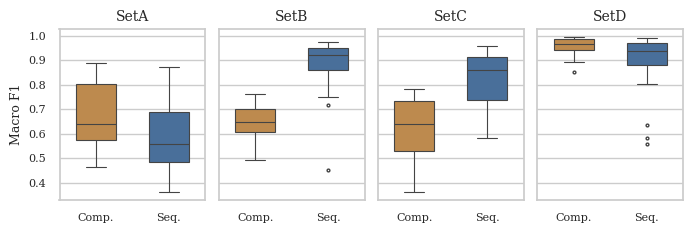

In [22]:
# ── Figure 1: Boxplot per network, paired models, paper-ready ────────────────
plot_data = avg[(avg['model'].isin(PAIRED_MODELS)) &
                (avg['metric']  == PRIMARY)].copy()

fig, axes = plt.subplots(1, 4, figsize=(7.0, 2.4), sharey=True)
for ax, net in zip(axes, NETWORKS):
    sub = plot_data[plot_data['network'] == net]
    sns.boxplot(data=sub, x='approach', y='mean_value', hue='approach',
                palette=PALETTE, ax=ax, width=0.55, fliersize=2,
                linewidth=0.8, legend=False)
    ax.set_title(net)
    ax.set_xlabel('')
    ax.set_xticklabels(['Comp.', 'Seq.'])
axes[0].set_ylabel('Macro F1')
for ax in axes[1:]:
    ax.set_ylabel('')
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig_q1_boxplot.pdf', bbox_inches='tight')
plt.show()

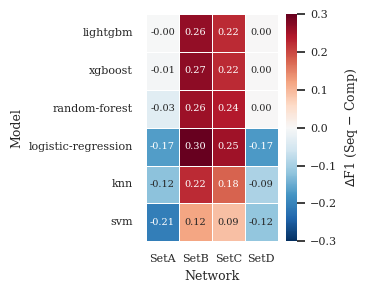

In [23]:
# ── Figure 2: Model × network ΔF1 heatmap, paper-ready ───────────────────────
heat_data = (stat_df.groupby(['model', 'network'])['delta_f1']
             .mean().unstack('network').reindex(columns=NETWORKS))
heat_data = heat_data.loc[
    heat_data.mean(axis=1).sort_values(ascending=False).index]

fig, ax = plt.subplots(figsize=(3.6, 3.0))
sns.heatmap(heat_data, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            vmin=-0.30, vmax=0.30, linewidths=0.4, ax=ax,
            cbar_kws={'label': r'$\Delta$F1 (Seq $-$ Comp)'},
            annot_kws={'size': 7})
ax.set_xlabel('Network')
ax.set_ylabel('Model')
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig_q1_heatmap.pdf', bbox_inches='tight')
plt.show()

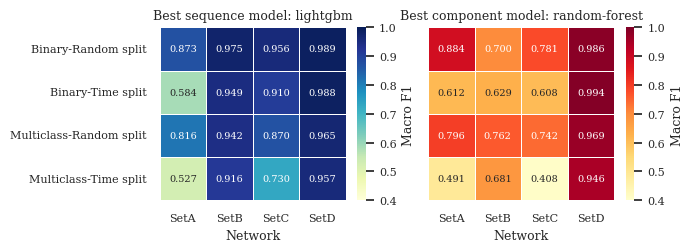

In [24]:
# ── Figure 3: Best model per approach, paper-ready ───────────────────────────
# Uses seq_heat, comp_heat, best_seq_model, best_comp_model from In [17]

fig, axes = plt.subplots(1, 2, figsize=(7.0, 2.6), sharey=True)
for ax, h, title, cmap in [
        (axes[0], seq_heat,
         f'Best sequence model: {best_seq_model}',  'YlGnBu'),
        (axes[1], comp_heat,
         f'Best component model: {best_comp_model}', 'YlOrRd')]:
    sns.heatmap(h, annot=True, fmt='.3f', cmap=cmap,
                vmin=0.4, vmax=1.0, linewidths=0.4, ax=ax,
                cbar_kws={'label': 'Macro F1'},
                annot_kws={'size': 7})
    ax.set_title(title, fontsize=9)
    ax.set_xlabel('Network')
    ax.set_ylabel('')
    ax.tick_params(axis='x', rotation=0)
    ax.tick_params(axis='y', rotation=0)
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig_q1_best_model.pdf', bbox_inches='tight')
plt.show()